In [1]:
import numpy as np

import os

from nbodykit.lab import *
from nbodykit import setup_logging, style

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import SymLogNorm

In [2]:
from baryonification.baryonification.params import par
from baryonification.baryonification.cosmo import cosmo
from baryonification.baryonification.displ import displace
from baryonification.baryonification.halo_displ import displace_haloes

from miniramses.utils.py.miniramses import rd_info
from miniramses.utils.py.miniramses import Info

In [3]:
#initialise parameters

par = par()

if par.code.multicomp:
    comp = 'multicomp' #'multicomp' or 'singlecomp'
else:
    comp = 'singlecomp'

size = par.code.size #'big' or 'small'

par.files.transfct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/CDM_PLANCK_tk.dat"
par.files.cosmofct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/cosmofct.dat"
par.files.displfct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/displfct.dat"
par.files.halofile_format = "ramses"
par.files.partfile_format = "ramses"
if size == 'big':
    par.files.partfile_in = "/scratch/gpfs/rt3504/bigbox/output_00011"
    par.files.halofile_in = "/scratch/gpfs/rt3504/bigbox/output_00011"
elif size == 'small':
    par.files.halofile_in = "/home/jamesdr/scratch/smallbox/output_00011"
    par.files.partfile_in = "/home/jamesdr/scratch/smallbox/output_00011"
par.files.partfile_out = "/home/jamesdr/usrp2024/{}_{}/partfile_out.std".format(comp,size)
par.files.halofile_out = "/home/jamesdr/usrp2024/{}_{}/halofile_out.std".format(comp,size)

Found 134217728 particles


In [4]:
import re

# Extracting the path using regular expression
path = re.match(r'(.*/{}box/)'.format(size), par.files.partfile_in).group(1)

# Extracting the number as an integer
nout = int(re.match(r'.*/output_(\d+)', par.files.partfile_in).group(1))

i = rd_info(nout, path=path)
unit_l = i.unit_l
unit_d = i.unit_d #g/cm^3
unit_m = unit_d * (unit_l)**3.0
unit_m_in_Msol_per_h = unit_m / (1.989e33) * par.cosmo.h0
unit_l_in_Mpc_per_h = unit_l / (3.086e24) * par.cosmo.h0

In [5]:
from baryonification.baryonification.io import read_nbody_file

In [6]:
p_header, non_displaced_particles = read_nbody_file(par)

Found 134217728 particles


In [7]:
cosmo(par);

Normalizing power-spectrum done!


In [8]:
displace(par);

Found 134217728 particles
Found 132551 clumps
Converting r200b, M200b, and c200b to r200c, M200c, and c200c


/home/jamesdr/.conda/envs/usrp2024/lib/python3.8/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Done!
N_cpu =  1
building tree..
...done!
Nhalo_chunk =  171626
Baryon displacements: 0.16725498 0.16768931 0.16721177
DM displacements: 0.0010824485 0.0010418223 0.0012036978
Saving baryons!
Om =  0.27524456
Total number of star particles 8195248


In [9]:
if comp == 'multicomp':
    def read_displaced_particles(file):

        Lbox   = unit_l / (3.086e24) * par.cosmo.h0
        N_chunk = 1
        L_chunk = Lbox/N_chunk
    
        Om = i.omega_m
        z  = par.cosmo.z
    
        f = open(file, 'r')

        #header
        p_header_dt = np.dtype([('a','>d'),('Npart','>i'),('dim','>i'),('Ngas','>i'),('Ndm','>i'),('Nstar','>i'),('buffer','>i')])
        p_header = np.fromfile(f, dtype=p_header_dt, count=1, sep='')
    
        #gas
        p_gas_dt = np.dtype([('mass','>f4'),('x', '>f4'),('y', '>f4'),('z', '>f4'),('vx', '>f4'),('vy', '>f4'),\
                               ('vz', '>f4'),('rho','>f4'),('temp','>f4'),('hsmooth','>f4'),('metals','>f4'),('phi','>f4')])
        p_gas = np.fromfile(f, dtype=p_gas_dt, count=int(p_header['Ngas']), sep='')
    
        #dm
        p_dm_dt   = np.dtype([('mass','>f4'),("x",'>f4'),("y",'>f4'),("z",'>f4'),("vx",'>f4'),("vy",'>f4'),("vz",'>f4'),\
                                ("eps",'>f4'),("phi",'>f4')])
        p_dm = np.fromfile(f, dtype=p_dm_dt, count=int(p_header['Ndm']), sep='')
    
        #stars
        p_star_dt = np.dtype([('mass','>f4'),('x', '>f4'),('y', '>f4'),('z', '>f4'),('vx', '>f4'),('vy', '>f4'),\
                                 ('vz', '>f4'),('metals','>f4'),('tform','>f4'),('eps','>f4'),('phi','>f4')])
        p_star = np.fromfile(f, dtype=p_star_dt, count=int(p_header['Nstar']), sep='')

        #convert to Mpc/h
        p_gas['x']=Lbox*(p_gas['x']+0.5)
        p_gas['y']=Lbox*(p_gas['y']+0.5)
        p_gas['z']=Lbox*(p_gas['z']+0.5)
        p_dm['x']=Lbox*(p_dm['x']+0.5)
        p_dm['y']=Lbox*(p_dm['y']+0.5)
        p_dm['z']=Lbox*(p_dm['z']+0.5)
        p_star['x']=Lbox*(p_star['x']+0.5)
        p_star['y']=Lbox*(p_star['y']+0.5)
        p_star['z']=Lbox*(p_star['z']+0.5)

        #convert to Mstar/h
        print("Om = ", np.sum(p_gas['mass'])+np.sum(p_dm['mass'])+np.sum(p_star['mass']))
        p_gas['mass'] = p_gas['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
        p_dm['mass'] = p_dm['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
        p_star['mass'] = p_star['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
        
        print('Reading tipsy-file done!')
    
        #split particles into chunks
        p_gas_list   = []
        for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            x_max = x_min + L_chunk
            if (x_max == Lbox):
                x_max = 1.00001*x_max
            for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                y_max =y_min + L_chunk
                if (y_max == Lbox):
                        y_max = 1.00001*y_max
                for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                    z_max = z_min + L_chunk
                    if (z_max == Lbox):
                            z_max = 1.00001*z_max
                    ID_gas = np.where((p_gas['x']>=x_min) & (p_gas['x']<x_max) & (p_gas['y']>=y_min) & (p_gas['y']<y_max) & (p_gas['z']>=z_min) & (p_gas['z']<z_max))
                    p_gas_list += [p_gas[ID_gas]]
                
        #split particles into chunks
        p_dm_list   = []
        for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            x_max = x_min + L_chunk
            if (x_max == Lbox):
                x_max = 1.00001*x_max
            for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                y_max =y_min + L_chunk
                if (y_max == Lbox):
                        y_max = 1.00001*y_max
                for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                    z_max = z_min + L_chunk
                    if (z_max == Lbox):
                            z_max = 1.00001*z_max
                    ID_dm = np.where((p_dm['x']>=x_min) & (p_dm['x']<x_max) & (p_dm['y']>=y_min) & (p_dm['y']<y_max) & (p_dm['z']>=z_min) & (p_dm['z']<z_max))
                    p_dm_list += [p_dm[ID_dm]]
                
        #split particles into chunks
        p_star_list   = []
        for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            x_max = x_min + L_chunk
            if (x_max == Lbox):
                x_max = 1.00001*x_max
            for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                y_max =y_min + L_chunk
                if (y_max == Lbox):
                        y_max = 1.00001*y_max
                for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                    z_max = z_min + L_chunk
                    if (z_max == Lbox):
                            z_max = 1.00001*z_max
                    ID_star = np.where((p_star['x']>=x_min) & (p_star['x']<x_max) & (p_star['y']>=y_min) & (p_star['y']<y_max) & (p_star['z']>=z_min) & (p_star['z']<z_max))
                    p_star_list += [p_star[ID_star]]
   
        pl = 0
        for pp in p_gas_list:
            pl += len(pp)
        if (pl != len(p_gas)):
            print('Chunking: particle number not conserved! Exit.')
            exit()

        pl = 0
        for pp in p_dm_list:
            pl += len(pp)
        if (pl != len(p_dm)):
            print('Chunking: particle number not conserved! Exit.')
            exit()
    
        pl = 0
        for pp in p_star_list:
            pl += len(pp)
        if (pl != len(p_star)):
            print('Chunking: particle number not conserved! Exit.')
            exit()
    
        return p_header, p_gas_list, p_dm_list, p_star_list
    
elif comp == 'singlecomp':
    def read_displaced_particles(file):

        Lbox   = unit_l / (3.086e24) * par.cosmo.h0
        N_chunk = 1
        L_chunk = Lbox/N_chunk
    
        Om = i.omega_m
        z  = par.cosmo.z
    
        f = open(file, 'r')

        #header
        p_header_dt = np.dtype([('a','>d'),('Npart','>i'),('dim','>i'),('Ngas','>i'),('Ndm','>i'),('Nstar','>i'),('buffer','>i')])
        p_header = np.fromfile(f, dtype=p_header_dt, count=1, sep='')
    
        #dm
        p_dm_dt   = np.dtype([('mass','>f4'),("x",'>f4'),("y",'>f4'),("z",'>f4'),("vx",'>f4'),("vy",'>f4'),("vz",'>f4'),\
                                ("eps",'>f4'),("phi",'>f4')])
        p_dm = np.fromfile(f, dtype=p_dm_dt, count=int(p_header['Ndm']), sep='')

        #convert to Mpc/h
        p_dm['x']=Lbox*(p_dm['x']+0.5)
        p_dm['y']=Lbox*(p_dm['y']+0.5)
        p_dm['z']=Lbox*(p_dm['z']+0.5)

        #convert to Mstar/h
        print("Om = ", np.sum(p_dm['mass']))
        p_dm['mass'] = p_dm['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
        
        print('Reading tipsy-file done!')
                
        #split particles into chunks
        p_dm_list   = []
        for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            x_max = x_min + L_chunk
            if (x_max == Lbox):
                x_max = 1.00001*x_max
            for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                y_max =y_min + L_chunk
                if (y_max == Lbox):
                        y_max = 1.00001*y_max
                for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                    z_max = z_min + L_chunk
                    if (z_max == Lbox):
                            z_max = 1.00001*z_max
                    ID_dm = np.where((p_dm['x']>=x_min) & (p_dm['x']<x_max) & (p_dm['y']>=y_min) & (p_dm['y']<y_max) & (p_dm['z']>=z_min) & (p_dm['z']<z_max))
                    p_dm_list += [p_dm[ID_dm]]
   
        pl = 0
        for pp in p_dm_list:
            pl += len(pp)
        if (pl != len(p_dm)):
            print('Chunking: particle number not conserved! Exit.')
            exit()
    
        return p_header, p_dm_list

In [10]:
if comp=='multicomp':    
    p_displaced_header, displaced_gas, displaced_dm, displaced_stars = read_displaced_particles("/home/jamesdr/usrp2024/{}_{}/partfile_out.std".format(comp,size))
elif comp=='singlecomp':
    p_displaced_header, displaced_dm = read_displaced_particles("/home/jamesdr/usrp2024/{}_{}/partfile_out.std".format(comp,size))

Om =  0.27524456
Reading tipsy-file done!


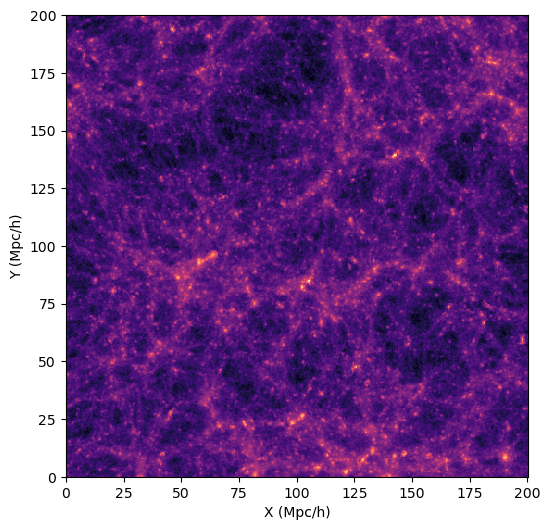

In [11]:
if comp=='multicomp':
    hist, xedges, yedges = np.histogram2d(displaced_gas[0]['x'], displaced_gas[0]['y'],bins=500)
    hist=hist.T

    plt.figure(figsize=(8, 6))
    plt.imshow(hist, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], norm='log', cmap='magma')
    
    # Adding labels and title
    plt.xlabel('X (Mpc/h)')
    plt.ylabel('Y (Mpc/h)')

    ax = plt.gca()
    ax.set_facecolor('black')

    plt.savefig(os.path.join('{}_{}'.format(comp, size), 'displaced_gas.pdf'), bbox_inches='tight')

    plt.show()

elif comp=='singlecomp':
    pass

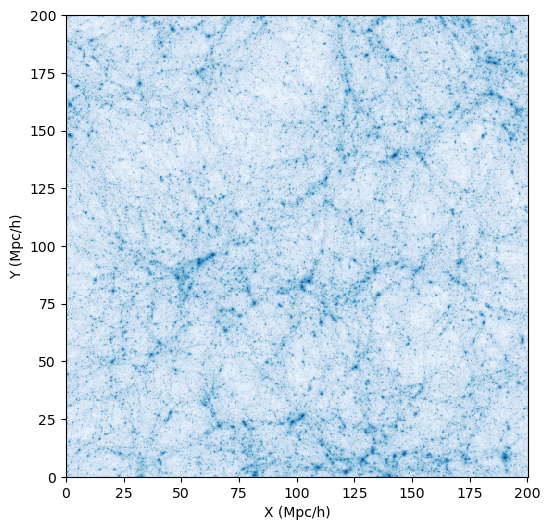

In [12]:
hist, xedges, yedges = np.histogram2d(displaced_dm[0]['x'], displaced_dm[0]['y'],bins=500)
hist=hist.T

plt.figure(figsize=(8, 6))
plt.imshow(hist, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], norm='log', cmap='Blues')
    
# Adding labels and title
plt.xlabel('X (Mpc/h)')
plt.ylabel('Y (Mpc/h)')

plt.savefig(os.path.join('{}_{}'.format(comp, size), 'displaced_dm.pdf'), bbox_inches='tight')

plt.show()

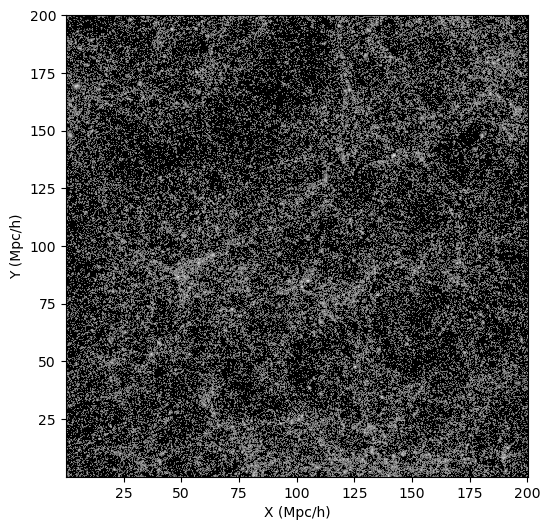

In [13]:
if comp=='multicomp':
    hist, xedges, yedges = np.histogram2d(displaced_stars[0]['x'], displaced_stars[0]['y'],bins=500)
    hist=hist.T

    plt.figure(figsize=(8, 6))
    plt.imshow(hist, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], norm='log', cmap='gray')
    
    # Adding labels and title
    plt.xlabel('X (Mpc/h)')
    plt.ylabel('Y (Mpc/h)')

    ax = plt.gca()
    ax.set_facecolor('black')

    plt.savefig(os.path.join('{}_{}'.format(comp, size), 'displaced_stars.pdf'), bbox_inches='tight')

    plt.show()

elif comp=='singlecomp':
    pass

In [14]:
plt.style.use(style.notebook)
setup_logging()

In [15]:
if comp=='multicomp':
    DMO = ArrayCatalog({'Position' : np.vstack((non_displaced_particles[0]['x'],non_displaced_particles[0]['y'],non_displaced_particles[0]['z'])).T})

    DM = ArrayCatalog({'Position' : np.vstack((displaced_dm[0]['x'],displaced_dm[0]['y'],displaced_dm[0]['z'])).T})
    gas = ArrayCatalog({'Position' : np.vstack((displaced_gas[0]['x'],displaced_gas[0]['y'],displaced_gas[0]['z'])).T})
    star = ArrayCatalog({'Position' : np.vstack((displaced_stars[0]['x'],displaced_stars[0]['y'],displaced_stars[0]['z'])).T})

    DMO['Mass'] = 1.0
    DM['Mass'] = displaced_dm[0]['mass'][0]/(displaced_dm[0]['mass'][0] + displaced_gas[0]['mass'][0] + displaced_stars[0]['mass'][0])
    gas['Mass'] = displaced_gas[0]['mass'][0]/(displaced_dm[0]['mass'][0] + displaced_gas[0]['mass'][0] + displaced_stars[0]['mass'][0])
    star['Mass'] = displaced_stars[0]['mass'][0]/(displaced_dm[0]['mass'][0] + displaced_gas[0]['mass'][0] + displaced_stars[0]['mass'][0])

    m_DMO = DMO['Mass']
    m_DM = DM['Mass']
    m_gas = gas['Mass']
    m_star = star['Mass']

    combined = MultipleSpeciesCatalog(['DM', 'gas', 'star'], DM, gas, star)
elif comp=='singlecomp':
    DMO = ArrayCatalog({'Position' : np.vstack((non_displaced_particles[0]['x'],non_displaced_particles[0]['y'],non_displaced_particles[0]['z'])).T})

    DM = ArrayCatalog({'Position' : np.vstack((displaced_dm[0]['x'],displaced_dm[0]['y'],displaced_dm[0]['z'])).T})
    
    DMO['Mass'] = 1.0
    DM['Mass'] = 1.0
    
    m_DMO = DMO['Mass']
    m_DM = DM['Mass']

In [16]:
if size=='big':
    Nmesh=2048
elif size=='small':
    Nmesh=1024

if comp=='multicomp':
    DMO_mesh = DMO.to_mesh(resampler='tsc', Nmesh=Nmesh, BoxSize=unit_l_in_Mpc_per_h, compensated=True, position='Position', weight='Mass')

    DM_mesh = DM.to_mesh(resampler='tsc', Nmesh=Nmesh, BoxSize=unit_l_in_Mpc_per_h, compensated=True, position='Position', weight='Mass')
    gas_mesh = gas.to_mesh(resampler='tsc', Nmesh=Nmesh, BoxSize=unit_l_in_Mpc_per_h, compensated=True, position='Position', weight='Mass')
    star_mesh = star.to_mesh(resampler='tsc', Nmesh=Nmesh, BoxSize=unit_l_in_Mpc_per_h, compensated=True, position='Position', weight='Mass')

    combined_mesh = combined.to_mesh(resampler='tsc', Nmesh=Nmesh, BoxSize=unit_l_in_Mpc_per_h, compensated=True, position='Position', weight='Mass')
elif comp=='singlecomp':
    DMO_mesh = DMO.to_mesh(resampler='tsc', Nmesh=Nmesh, BoxSize=unit_l_in_Mpc_per_h, compensated=True, position='Position', weight='Mass')

    DM_mesh = DM.to_mesh(resampler='tsc', Nmesh=Nmesh, BoxSize=unit_l_in_Mpc_per_h, compensated=True, position='Position', weight='Mass')

In [17]:
if comp=='multicomp':
    r_DMO = FFTPower(DMO_mesh, mode='1d', dk=0.05, kmin=0.05)

    r_DM = FFTPower(DM_mesh, mode='1d', dk=0.05, kmin=0.05)
    r_gas = FFTPower(gas_mesh, mode='1d', dk=0.05, kmin=0.05)
    r_star = FFTPower(star_mesh, mode='1d', dk=0.05, kmin=0.05)

    r_combined = FFTPower(combined_mesh, mode='1d', dk=0.05, kmin=0.05)
elif comp=='singlecomp':
    r_DMO = FFTPower(DMO_mesh, mode='1d', dk=0.05, kmin=0.05)

    r_DM = FFTPower(DM_mesh, mode='1d', dk=0.05, kmin=0.05)

[ 000026.83 ]   0: 04-02 11:24  CatalogMesh     INFO     Chunk 0 ~ 4194304 / 134217728 
[ 000029.42 ]   0: 04-02 11:24  CatalogMesh     INFO     painted 4194304 out of 134217728 objects to mesh
[ 000029.42 ]   0: 04-02 11:24  CatalogMesh     INFO     Chunk 4194304 ~ 8388608 / 134217728 
[ 000031.71 ]   0: 04-02 11:24  CatalogMesh     INFO     painted 8388608 out of 134217728 objects to mesh
[ 000031.71 ]   0: 04-02 11:24  CatalogMesh     INFO     Chunk 8388608 ~ 12582912 / 134217728 
[ 000034.00 ]   0: 04-02 11:24  CatalogMesh     INFO     painted 12582912 out of 134217728 objects to mesh
[ 000034.00 ]   0: 04-02 11:24  CatalogMesh     INFO     Chunk 12582912 ~ 16777216 / 134217728 
[ 000036.31 ]   0: 04-02 11:24  CatalogMesh     INFO     painted 16777216 out of 134217728 objects to mesh
[ 000036.31 ]   0: 04-02 11:24  CatalogMesh     INFO     Chunk 16777216 ~ 20971520 / 134217728 
[ 000038.61 ]   0: 04-02 11:24  CatalogMesh     INFO     painted 20971520 out of 134217728 objects to mes

In [18]:
if comp=='multicomp':
    Pk_DMO = r_DMO.power

    Pk_DM = r_DM.power
    Pk_gas = r_gas.power
    Pk_star = r_star.power

    Pk_combined = r_combined.power
elif comp=='singlecomp':
    Pk_DMO = r_DMO.power

    Pk_DM = r_DM.power

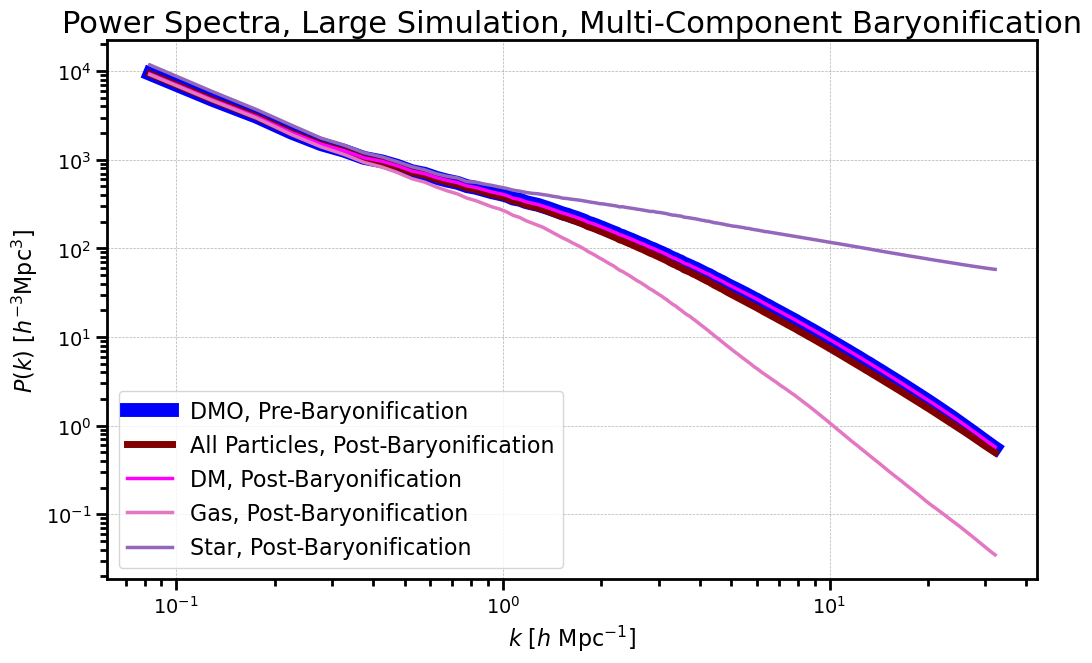

In [19]:
# print the shot noise subtracted P(k)
if comp=='multicomp':
    plt.loglog(Pk_DMO['k'], Pk_DMO['power'].real - Pk_DMO.attrs['shotnoise'], color='blue', linewidth=10.0, label='DMO, Pre-Baryonification')

    plt.loglog(Pk_combined['k'], Pk_combined['power'].real - Pk_combined.attrs['shotnoise'], color='maroon', linewidth=5.0, label='All Particles, Post-Baryonification')

    plt.loglog(Pk_DM['k'], Pk_DM['power'].real - Pk_DM.attrs['shotnoise'], color='magenta', label='DM, Post-Baryonification')
    plt.loglog(Pk_gas['k'], Pk_gas['power'].real - Pk_gas.attrs['shotnoise'], color='tab:pink', label='Gas, Post-Baryonification')
    plt.loglog(Pk_star['k'], Pk_star['power'].real - Pk_star.attrs['shotnoise'], color='tab:purple', label='Star, Post-Baryonification')
elif comp=='singlecomp':
    plt.loglog(Pk_DMO['k'], Pk_DMO['power'].real - Pk_DMO.attrs['shotnoise'], color='blue', linewidth=10.0, label='DMO, Pre-Baryonification')
    plt.loglog(Pk_DM['k'], Pk_DM['power'].real - Pk_DM.attrs['shotnoise'], color='magenta', label='DM, Post-Baryonification')
    
# format the axes
plt.xlabel(r"$k$ [$h \ \mathrm{Mpc}^{-1}$]")
plt.ylabel(r"$P(k)$ [$h^{-3}\mathrm{Mpc}^3$]")
if size=='small':
    if comp=='singlecomp':
        plt.title(r"Power Spectra, Small Simulation, Single-Component Baryonification")
    elif comp=='multicomp':
        plt.title(r"Power Spectra, Small Simulation, Multi-Component Baryonification")
if size=='big':
    if comp=='singlecomp':
        plt.title(r"Power Spectra, Large Simulation, Single-Component Baryonification")
    elif comp=='multicomp':
        plt.title(r"Power Spectra, Large Simulation, Multi-Component Baryonification")
plt.legend()
plt.savefig(os.path.join('{}_{}'.format(comp, size), 'power_spectra.pdf'), bbox_inches='tight')

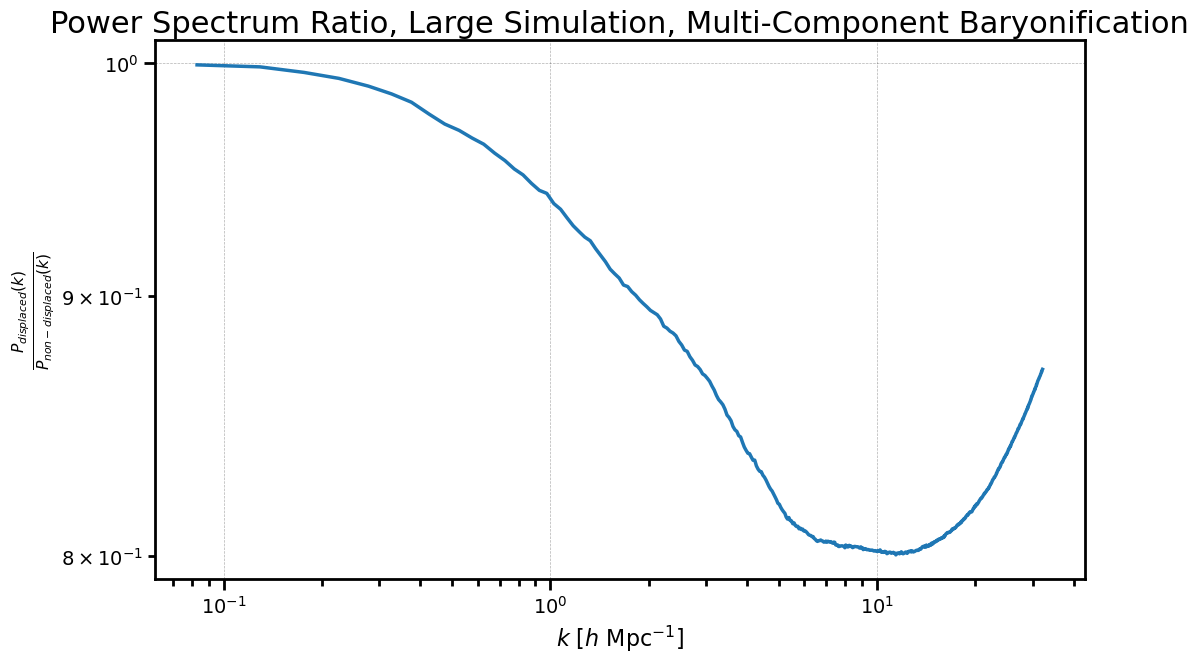

In [20]:
if comp=='multicomp':
    ratio = (Pk_combined['power'].real)/(Pk_DMO['power'].real)
    plt.loglog(Pk_combined['k'], ratio);
elif comp=='singlecomp':
    ratio = (Pk_DM['power'].real)/(Pk_DMO['power'].real)
    plt.loglog(Pk_DM['k'], ratio);
# print the shot noise subtracted P(k)

# format the axes
plt.xlabel(r"$k$ [$h \ \mathrm{Mpc}^{-1}$]");
plt.ylabel(r"$\frac{P_{displaced}(k)}{P_{non-displaced}(k)}$");
if size=='small':
    if comp=='singlecomp':
        plt.title(r"Power Spectrum Ratio, Small Simulation, Single-Component Baryonification")
    elif comp=='multicomp':
        plt.title(r"Power Spectrum Ratio, Small Simulation, Multi-Component Baryonification")
if size=='big':
    if comp=='singlecomp':
        plt.title(r"Power Spectrum Ratio, Large Simulation, Single-Component Baryonification")
    elif comp=='multicomp':
        plt.title(r"Power Spectrum Ratio, Large Simulation, Multi-Component Baryonification")
plt.savefig(os.path.join('{}_{}'.format(comp, size), 'power_spectrum_ratio.pdf'), bbox_inches='tight')

In [21]:
import os
np.save(os.path.join('{}_{}'.format(comp, size), 'DMO_k'), Pk_DMO['k'])
np.save(os.path.join('{}_{}'.format(comp, size), 'DMO_shotnoise'), Pk_DMO.attrs['shotnoise'])

np.save(os.path.join('{}_{}'.format(comp, size), 'DM_k'), Pk_DM['k'])
np.save(os.path.join('{}_{}'.format(comp, size), 'DM_shotnoise'), Pk_DM.attrs['shotnoise'])

if comp=='multicomp':
    np.save(os.path.join('{}_{}'.format(comp, size), 'gas_k'), Pk_gas['k'])
    np.save(os.path.join('{}_{}'.format(comp, size), 'gas_shotnoise'), Pk_gas.attrs['shotnoise'])
    
    np.save(os.path.join('{}_{}'.format(comp, size), 'star_k'), Pk_star['k'])
    np.save(os.path.join('{}_{}'.format(comp, size), 'star_shotnoise'), Pk_star.attrs['shotnoise'])

    np.save(os.path.join('{}_{}'.format(comp, size), 'combined_k'), Pk_combined['k'])
    np.save(os.path.join('{}_{}'.format(comp, size), 'combined_shotnoise'), Pk_combined.attrs['shotnoise'])

np.save(os.path.join('{}_{}'.format(comp, size), 'DMO_P'), Pk_DMO['power'])
np.save(os.path.join('{}_{}'.format(comp, size), 'DM_P'), Pk_DM['power'])

if comp =='multicomp':
    np.save(os.path.join('{}_{}'.format(comp, size), 'gas_P'), Pk_gas['power'])
    np.save(os.path.join('{}_{}'.format(comp, size), 'star_P'), Pk_star['power'])

    np.save(os.path.join('{}_{}'.format(comp, size), 'combined_P'), Pk_combined['power'])

np.save(os.path.join('{}_{}'.format(comp, size), 'ratio'), ratio)

In [ ]:
if comp=='multicomp':
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'k_etacga=0.6.npy'), Pk_combined['k'])
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'ratio_etacga=0.6.npy'), ratio)
elif comp=='singlecomp':
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'k_etacga=0.6.npy'), Pk_DM['k'])
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'ratio_etacga=0.6.npy'), ratio)

In [23]:
if comp=='multicomp':
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'k_etastar=0.3.npy'), Pk_combined['k'])
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'ratio_etastar=0.3.npy'), ratio)
elif comp=='singlecomp':
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'k_etastar=0.3.npy'), Pk_DM['k'])
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'ratio_etastar=0.3.npy'), ratio)

In [24]:
if comp=='multicomp':
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'k_Mc=1e14.npy'), Pk_combined['k'])
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'ratio_Mc=1e14.npy'), ratio)
elif comp=='singlecomp':
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'k_Mc=1e14.npy'), Pk_DM['k'])
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'ratio_Mc=1e14.npy'), ratio)

In [25]:
if comp=='multicomp':
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'k_mu=0.4.npy'), Pk_combined['k'])
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'ratio_mu=0.4.npy'), ratio)
elif comp=='singlecomp':
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'k_mu=0.4.npy'), Pk_DM['k'])
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'ratio_mu=0.4.npy'), ratio)

In [26]:
if comp=='multicomp':
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'k_thej=4.0.npy'), Pk_combined['k'])
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'ratio_thej=4.0.npy'), ratio)
elif comp=='singlecomp':
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'k_thej=4.0.npy'), Pk_DM['k'])
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'ratio_thej=4.0.npy'), ratio)

In [27]:
if comp=='multicomp':
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'k_z=0.0.npy'), Pk_combined['k'])
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'ratio_z=0.0.npy'), ratio)
elif comp=='singlecomp':
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'k_z=0.0.npy'), Pk_DM['k'])
    np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'ratio_z=0.0.npy'), ratio)